Loading data from Phase1_Golden_Dataset.csv...

Features selected for training (16 columns):
['Crown base height [m]', 'Height [m]', 'Crown diameter [m]', 'Crown projection area, convex hull [m**2]', 'Crown projection area, concave hull [m**2]', 'Specie_Acer campestre', 'Specie_Acer pseudoplatanus', 'Specie_Carpinus betulus', 'Specie_Fagus sylvatica', 'Specie_Larix decidua', 'Specie_Picea abies', 'Specie_Pinus sylvestris', 'Specie_Prunus avium', 'Specie_Pseudotsuga menziesii', 'Specie_Quercus petraea', 'Specie_Salix caprea']

Training set size: 321 trees
Testing set size:  81 trees

Training Random Forest Regressor...

MODEL PERFORMANCE RESULTS
R-Squared (Accuracy): 0.9038 (Closer to 1.0 is better)
MAE (Mean Absolute Error): 3.07 cm
RMSE (Root Mean Sq Error): 3.96 cm


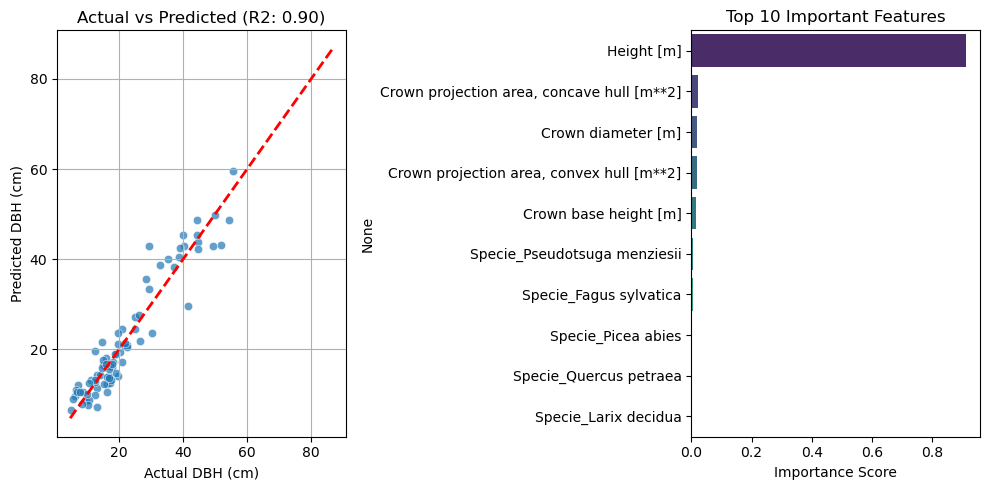

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

# ==========================================
# 1. LOAD DATA
# ==========================================
file_path = 'Phase1_Golden_Dataset.csv'
print(f"Loading data from {file_path}...")
df = pd.read_csv(file_path)

# ==========================================
# 2. FEATURE SELECTION
# ==========================================
# We need to drop columns that are NOT physical features or species info.
# We drop ID, Source, Date, Coordinates (unless spatial location is specific to your study), and the Target itself.
drop_cols = [
    'Tree_ID', 
    'Source', 
    'Date', 
    'Canopy condition', 
    'Latitude (EPSG:4326)', 
    'Longitude (EPSG:4326)', 
    'Easting [m]', 
    'Northing [m]', 
    'Height [m]_general', # Assuming we use the specific ULS Height
    'Target_DBH' # This is what we want to predict (y)
]

# Define X (Features) and y (Target)
X = df.drop(columns=drop_cols, errors='ignore') # errors='ignore' in case some cols don't exist
y = df['Target_DBH']

print(f"\nFeatures selected for training ({X.shape[1]} columns):")
print(list(X.columns))

# ==========================================
# 3. SPLIT DATA (80% Train, 20% Test)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} trees")
print(f"Testing set size:  {X_test.shape[0]} trees")

# ==========================================
# 4. TRAIN MODEL (Random Forest)
# ==========================================
print("\nTraining Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# ==========================================
# 5. EVALUATION
# ==========================================
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n" + "="*30)
print("MODEL PERFORMANCE RESULTS")
print("="*30)
print(f"R-Squared (Accuracy): {r2:.4f} (Closer to 1.0 is better)")
print(f"MAE (Mean Absolute Error): {mae:.2f} cm")
print(f"RMSE (Root Mean Sq Error): {rmse:.2f} cm")
print("="*30)

# ==========================================
# 6. VISUALIZATION
# ==========================================

# Plot 1: Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual DBH (cm)')
plt.ylabel('Predicted DBH (cm)')
plt.title(f'Actual vs Predicted (R2: {r2:.2f})')
plt.grid(True)

# Plot 2: Feature Importance (What matters most?)
plt.subplot(1, 2, 2)
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

# Updated to fix FutureWarning: Assigned y to hue and set legend=False
sns.barplot(x=feature_imp.values, y=feature_imp.index, hue=feature_imp.index, palette='viridis', legend=False)

plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()